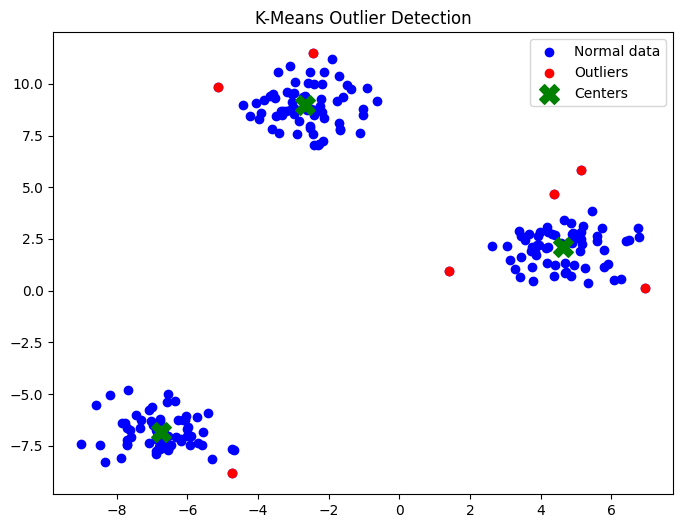

تعداد داده‌های پرت: 7


In [2]:
# نصب و وارد کردن کتابخانه‌ها
import numpy as np
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

# تولید داده نمونه
X, _ = make_blobs(n_samples=200, centers=3, cluster_std=1.0, random_state=42)

# اجرای K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)
labels = kmeans.labels_
centers = kmeans.cluster_centers_

# محاسبه فاصله هر نقطه تا مرکز خوشه خودش
distances = np.linalg.norm(X - centers[labels], axis=1)

# تشخیص داده‌های پرت (threshold = mean + 2*std)
threshold = np.mean(distances) + 2 * np.std(distances)
outliers = X[distances > threshold]

# نمایش داده‌ها و داده‌های پرت
plt.figure(figsize=(8,6))
plt.scatter(X[:, 0], X[:, 1], c='blue', label='Normal data')
plt.scatter(outliers[:, 0], outliers[:, 1], c='red', label='Outliers')
plt.scatter(centers[:, 0], centers[:, 1], c='green', marker='X', s=200, label='Centers')
plt.title("K-Means Outlier Detection")
plt.legend()
plt.show()

# چاپ تعداد داده‌های پرت
print(f"تعداد داده‌های پرت: {len(outliers)}")


In [3]:
print(f"تعداد داده‌های پرت: {len(outliers)}")


تعداد داده‌های پرت: 7


In [4]:
print(distances[:10])  # فاصله ۱۰ نقطه اول


[1.90511516 2.62173106 0.93743554 2.13686657 1.09431713 0.84511681
 0.36080531 0.63852858 2.60483032 0.90647285]


In [5]:
import pandas as pd

df_outliers = pd.DataFrame(outliers, columns=['X1','X2'])
df_outliers.to_csv('outliers.csv', index=False)
print("فایل outliers.csv ساخته شد.")


فایل outliers.csv ساخته شد.


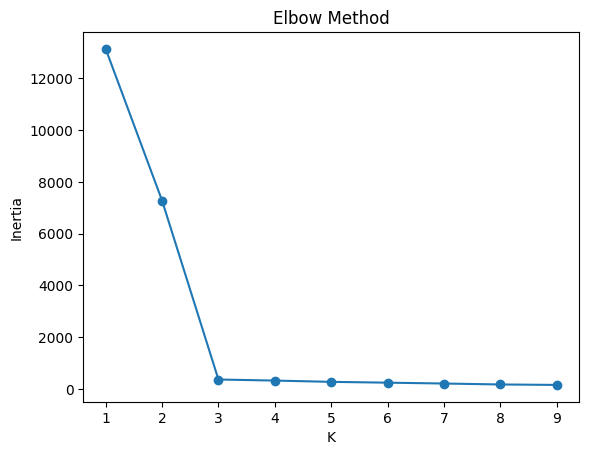

In [6]:
inertia = []
K_range = range(1, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    inertia.append(km.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()
